# Color Gradient LB

Two-component color gradient lattice Boltzmann simulation of a spherical droplet.
Component **a** is the solvent, component **b** is the droplet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit
from IPython.display import HTML

import espressomd
import espressomd.lb

## Droplet equilibration and visualization

In [28]:
# factors for MD/LB unit conversion
AGRID = 1.0
TAU = 0.1

RHO_0 = 1.0 # density of the fluid (same for both components)
EPSILON = 1e-6 # density fraction outside of fluid (in other component)

VISCOSITY_LB = 1.0 / 6.0 # gives omega = 1.0
VISCOSITY_MD = VISCOSITY_LB / (TAU / AGRID**2)

RADIUS = 5.0 # Droplet radius
DOMAIN_SIZE = int(4*RADIUS) # system size
SMOOTHING_WIDTH = 2.0 # for tanh interpolation at droplet interface

SIGMA_LB = 0.005 # surface tension
SIGMA_MD = SIGMA_LB / (TAU**2 / AGRID**2)
print(SIGMA_MD)
BETA = 0.8    # dimensionless interface thickness parameter for recoloring

0.4999999999999999


In [3]:
def tanh_interpolation(distances, radius, smoothing_width, rho_outer, rho_inner):
    """Smooth tanh interface profile."""
    return (rho_outer-rho_inner) /2.0 *(np.tanh((distances-radius) /smoothing_width *2.64665) - 1.0) + rho_outer

In [4]:
def make_droplet(grid_size, radius, smoothing_width, rho_0, epsilon, square = False):
    """Generate initial density fields for a spherical/square droplet."""
    x = np.arange(grid_size) + 0.5
    xx, yy, zz = np.meshgrid(x, x, x, indexing='ij')
    center = grid_size / 2.0

    if square:
        # Square with side length=radius
        distances = np.maximum(np.maximum(np.abs(xx - center), np.abs(yy - center)), np.abs(zz - center))
    else:    
        # Sphere
        distances = np.sqrt((xx - center)**2 + (yy - center)**2 + (zz - center)**2)

    rho_a = tanh_interpolation(distances, radius, smoothing_width,
                               rho_0, epsilon * rho_0)
    rho_b = tanh_interpolation(distances, radius, smoothing_width,
                               epsilon * rho_0, rho_0)
    return rho_a, rho_b

In [5]:
def read_densities(lbf, grid_size):
    """Read per-node densities into two 3D arrays."""
    densities = np.copy(lbf[:, :, :].density)
    rho_a = densities[:, :, :, 0]
    rho_b = densities[:, :, :, 1]
    return rho_a, rho_b

In [6]:
def plot_densities(rho_a, rho_b, title=''):
    """Plot a z-midplane slice of both density fields."""
    z_mid = rho_a.shape[2] // 2
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    im1 = ax1.imshow(rho_a[:, :, z_mid].T, origin='lower', cmap='Blues', vmin=0, vmax=RHO_0)
    ax1.set_title('rho_a (solvent)')
    plt.colorbar(im1, ax=ax1)
    im2 = ax2.imshow(rho_b[:, :, z_mid].T, origin='lower', cmap='Reds', vmin=0, vmax=RHO_0)
    ax2.set_title('rho_b (droplet)')
    plt.colorbar(im2, ax=ax2)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [7]:
def find_radius_1d(profile, coords):
    """Find the droplet radius from a 1D density profile.

    Locates the two points where the profile crosses 0.5 (half-max)
    via linear interpolation, returns half the distance between them.
    """
    threshold = 0.5 * np.max(profile)
    above = profile > threshold
    crossings = []
    for i in range(len(above) - 1):
        if above[i] != above[i + 1]:
            # linear interpolation
            t = (threshold - profile[i]) / (profile[i + 1] - profile[i])
            crossings.append(coords[i] + t * (coords[i + 1] - coords[i]))
    if len(crossings) >= 2:
        return (crossings[-1] - crossings[0]) / 2.0
    return np.nan

In [8]:
def measure_radii(rho_b):
    """Measure droplet radius along 3 axes and 3 face diagonals."""
    N = rho_b.shape[0]
    c = N // 2
    coords = np.arange(N) + 0.5

    # Axes through center
    r_x = find_radius_1d(rho_b[:, c, c], coords)
    r_y = find_radius_1d(rho_b[c, :, c], coords)
    r_z = find_radius_1d(rho_b[c, c, :], coords)

    # Face diagonals through center (scale coords by sqrt(2) for true distance)
    diag_len = min(N - c, c)
    idx = np.arange(-diag_len, diag_len)
    diag_coords = idx * np.sqrt(2)

    prof_xy = np.array([rho_b[c + i, c + i, c] for i in idx])
    prof_xz = np.array([rho_b[c + i, c, c + i] for i in idx])
    prof_yz = np.array([rho_b[c, c + i, c + i] for i in idx])

    r_xy = find_radius_1d(prof_xy, diag_coords)
    r_xz = find_radius_1d(prof_xz, diag_coords)
    r_yz = find_radius_1d(prof_yz, diag_coords)

    return {"x": r_x, "y": r_y, "z": r_z,
            "xy": r_xy, "xz": r_xz, "yz": r_yz}

### System setup

In [9]:
SQUARE = True # False for round droplet and True for square

In [10]:
system = espressomd.System(box_l=[DOMAIN_SIZE * AGRID] * 3)
system.time_step = TAU
system.cell_system.skin = 0.4

lbf = espressomd.lb.LBFluid(
    agrid=AGRID, density=RHO_0, tau=TAU,
    kinematic_viscosity=[VISCOSITY_MD, VISCOSITY_MD],
    sigma=SIGMA_MD, beta=BETA)
system.lb = lbf

rho_a_init, rho_b_init = make_droplet(DOMAIN_SIZE, RADIUS, SMOOTHING_WIDTH, RHO_0, EPSILON, square=SQUARE)

lbf[:, :, :].density = np.stack([rho_a_init, rho_b_init], axis=-1)
lbf.init_two_component()

### Initial state

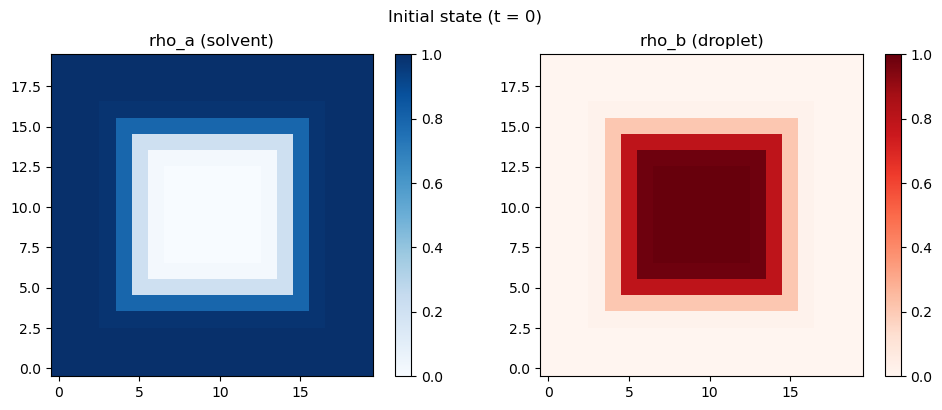

In [11]:
rho_a, rho_b = read_densities(lbf, DOMAIN_SIZE)
plot_densities(rho_a, rho_b, title='Initial state (t = 0)')

### Run simulation

In [12]:
N_FRAMES = 200
STEPS_PER_FRAME = 1

z_slice = DOMAIN_SIZE // 2
rho_a_frames = [rho_a[:, :, z_slice].copy()]
rho_b_frames = [rho_b[:, :, z_slice].copy()]

total_rho_a_init = np.sum(rho_a)
total_rho_b_init = np.sum(rho_b)
times = [0]
mass_a = [total_rho_a_init]
mass_b = [total_rho_b_init]
radii_history = [measure_radii(rho_b)]

print(f'Running {N_FRAMES} frames x {STEPS_PER_FRAME} steps '
      f'= {N_FRAMES * STEPS_PER_FRAME} total steps ...')
for i in range(N_FRAMES):
    system.integrator.run(STEPS_PER_FRAME)
    rho_a, rho_b = read_densities(lbf, DOMAIN_SIZE)

    t = (i + 1) * STEPS_PER_FRAME
    times.append(t)
    mass_a.append(np.sum(rho_a))
    mass_b.append(np.sum(rho_b))
    radii_history.append(measure_radii(rho_b))

    rho_a_frames.append(rho_a[:, :, z_slice].copy())
    rho_b_frames.append(rho_b[:, :, z_slice].copy())

    if (i + 1) % 25 == 0:
        print(f'  t = {t:5d}:  rho_a = {mass_a[-1]:.8f},  '
              f'rho_b = {mass_b[-1]:.8f}')

print('Done.')

Running 200 frames x 1 steps = 200 total steps ...
  t =    25:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =    50:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =    75:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =   100:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =   125:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =   150:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =   175:  rho_a = 6934.42260576,  rho_b = 1065.58539424
  t =   200:  rho_a = 6934.42260576,  rho_b = 1065.58539424
Done.


### Final state

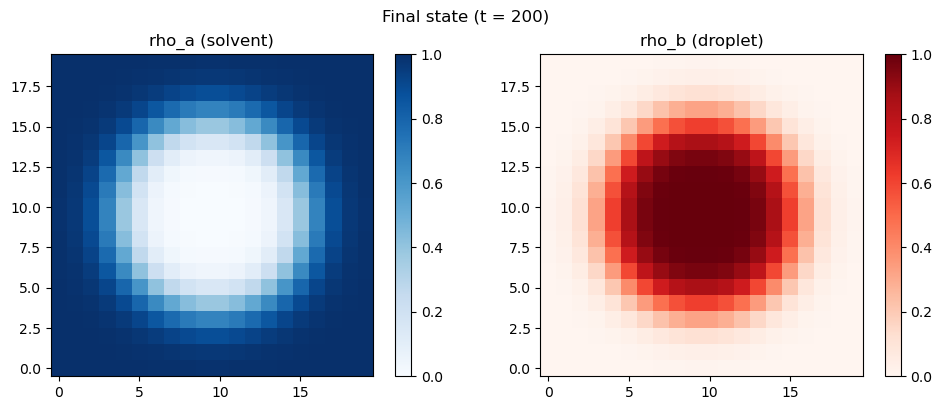

In [13]:
plot_densities(rho_a, rho_b, title=f'Final state (t = {times[-1]})')

### Animation

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(rho_a_frames[0].T, origin='lower', cmap='Blues', vmin=0, vmax=RHO_0)
ax1.set_title('rho_a (solvent)')
plt.colorbar(im1, ax=ax1)
im2 = ax2.imshow(rho_b_frames[0].T, origin='lower', cmap='Reds', vmin=0, vmax=RHO_0)
ax2.set_title('rho_b (droplet)')
plt.colorbar(im2, ax=ax2)
suptitle = fig.suptitle('t = 0')
plt.tight_layout()


def update(frame):
    im1.set_data(rho_a_frames[frame].T)
    im2.set_data(rho_b_frames[frame].T)
    suptitle.set_text(f't = {frame * STEPS_PER_FRAME}')
    return im1, im2, suptitle


anim = FuncAnimation(fig, update, frames=len(rho_a_frames), interval=50, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

### Mass conservation

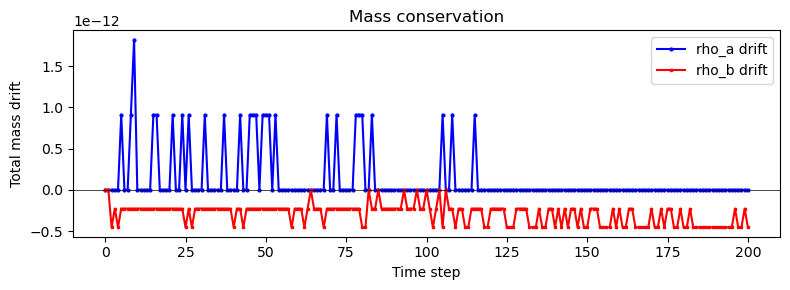

Max |drift| rho_a: 1.82e-12
Max |drift| rho_b: 4.55e-13


In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times, np.array(mass_a) - total_rho_a_init, 'b-o', markersize=2, label='rho_a drift')
ax.plot(times, np.array(mass_b) - total_rho_b_init, 'r-s', markersize=2, label='rho_b drift')
ax.set_xlabel('Time step')
ax.set_ylabel('Total mass drift')
ax.set_title('Mass conservation')
ax.legend()
ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()
print(f'Max |drift| rho_a: '
      f'{np.max(np.abs(np.array(mass_a) - total_rho_a_init)):.2e}')
print(f'Max |drift| rho_b: '
      f'{np.max(np.abs(np.array(mass_b) - total_rho_b_init)):.2e}')

### Radii & Anisotropy

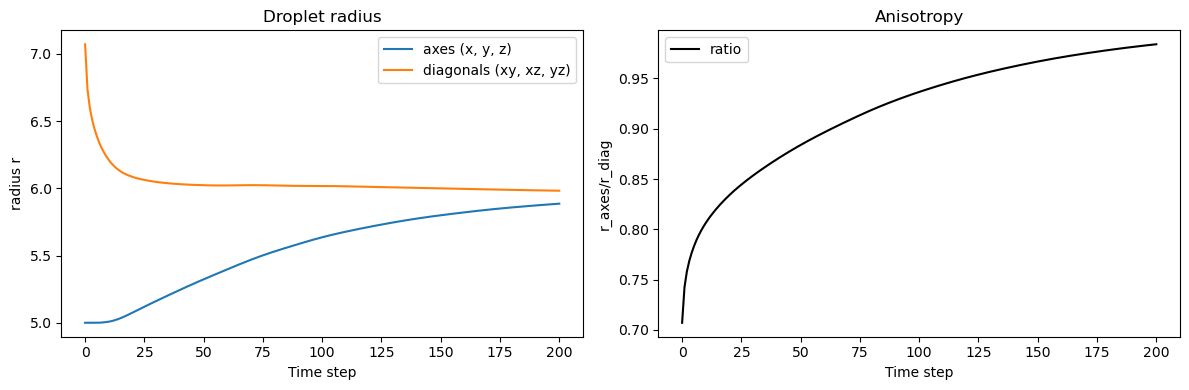

Final mean axis radius:     5.8857
Final mean diagonal radius: 5.9821


In [16]:
axes = ["x", "y", "z"]
diags = ["xy", "xz", "yz"]

r_axes = np.array([[h[d] for d in axes] for h in radii_history])
r_diags = np.array([[h[d] for d in diags] for h in radii_history])
r_axes_mean = np.mean(r_axes, axis=1)
r_diags_mean = np.mean(r_diags, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(times, r_axes_mean, label='axes (x, y, z)')
ax1.plot(times, r_diags_mean, label='diagonals (xy, xz, yz)')
ax1.set_xlabel('Time step')
ax1.set_ylabel('radius r')
ax1.set_title('Droplet radius')
ax1.legend()

ax2.plot(times, r_axes_mean/r_diags_mean, 'k', label = 'ratio')
ax2.set_xlabel('Time step')
ax2.set_ylabel('r_axes/r_diag')
ax2.set_title('Anisotropy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final mean axis radius:     {r_axes_mean[-1]:.4f}")
print(f"Final mean diagonal radius: {r_diags_mean[-1]:.4f}")

## Surface Tension Measurement

Measure the pressure difference $$\Delta p = p_\mathrm{in} - p_\mathrm{out}$$ across a spherical droplet interface for several radii $R$ via $$p=\rho\cdot c_s^2$$ where $c_s=\frac{1}{\sqrt{3}}$ is the speed of sound in lattice units.
According to Laplace's law, $$\Delta p = \frac{2\sigma}{R}$$ in 3D, so a linear fit of $\Delta p$ vs $1/R$ yields the surface tension coefficient $\sigma$.

In [49]:
EQUILIBRATION_STEPS = 700
MEASUREMENT_INTERVALS = 70
STEPS_PER_INTERVAL = 5

In [50]:
def measure_surface_tension(system, radius, domain_size):
    """Run a spherical droplet simulation and measure delta_p over time."""
    
    # Remove existing LB, resize box, create new LB
    system.lb = None
    system.box_l = [domain_size * AGRID] * 3

    lbf = espressomd.lb.LBFluid(
        agrid=AGRID, density=RHO_0, tau=TAU,
        kinematic_viscosity=[VISCOSITY_MD, VISCOSITY_MD],
        sigma=SIGMA_MD, beta=BETA)
    system.lb = lbf

    # Spherical droplet initialization
    rho_a_init, rho_b_init = make_droplet(domain_size, radius, SMOOTHING_WIDTH,
                                          RHO_0, EPSILON, square=False)

    lbf[:, :, :].density = np.stack([rho_a_init, rho_b_init], axis=-1)
    lbf.init_two_component()

    # Equilibration
    system.integrator.run(EQUILIBRATION_STEPS)
    
    c_s_sq_md = (1.0 / 3.0) * (AGRID / TAU)**2

    # Measurement
    delta_p_series = []
    for _ in range(MEASUREMENT_INTERVALS):
        system.integrator.run(STEPS_PER_INTERVAL)
        rho_a, rho_b = read_densities(lbf, domain_size)
        rho_total = rho_a + rho_b
        pressure = rho_total * c_s_sq_md  # p = rho * c_s^2

        phasefield = rho_a - rho_b
        inside_mask = phasefield < -0.5
        outside_mask = phasefield > 0.5

        if np.any(inside_mask) and np.any(outside_mask):
            p_in = np.mean(pressure[inside_mask])
            p_out = np.mean(pressure[outside_mask])
            delta_p_series.append(p_in - p_out)

    return np.array(delta_p_series)

In [51]:
def measure(radius):
    domain_size = int(3 * radius)
    print(f"R = {radius:.2f}, domain = {domain_size}^3:")
    delta_p = measure_surface_tension(system, radius, domain_size)
    mean = np.mean(delta_p)
    error = np.std(delta_p, ddof=1) / np.sqrt(len(delta_p))
    results[radius] = {"delta_p": delta_p, "mean": mean, "error": error}
    print(f"  delta_p = {mean:.4e} +/- {error:.4e}")

In [52]:
results = {}

In [53]:
measure(1/0.06)

R = 16.67, domain = 50^3:
  delta_p = 5.6885e-02 +/- 2.3870e-04


In [54]:
measure(1/0.05)

R = 20.00, domain = 60^3:
  delta_p = 4.7370e-02 +/- 4.1670e-04


In [55]:
measure(1/0.04)

R = 25.00, domain = 75^3:
  delta_p = 3.8611e-02 +/- 5.6488e-04


In [56]:
measure(1/0.03)

R = 33.33, domain = 100^3:
  delta_p = 2.8968e-02 +/- 7.3493e-04



Measured surface tension: sigma = 0.476455
Input surface tension:   sigma = 0.4999999999999999


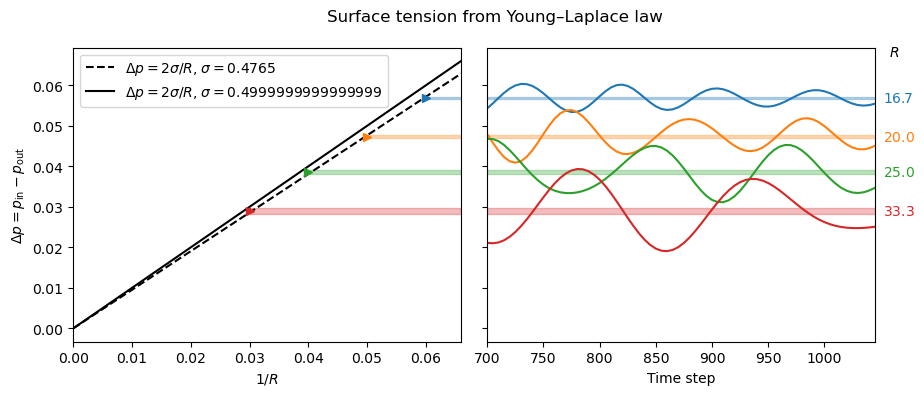

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

delta_ps = []
error_ps = []

for radius in results.keys():
    res = results[radius]
    inverse_r = 1.0 / radius
    delta_ps.append(res["mean"])

    steps = (np.arange(len(res["delta_p"])) * STEPS_PER_INTERVAL + EQUILIBRATION_STEPS)
    line, = ax2.plot(steps, res["delta_p"])
    color = line.get_color()
    ax2.fill_between(steps,
                     np.full_like(steps, res["mean"] - res["error"], dtype=float),
                     np.full_like(steps, res["mean"] + res["error"], dtype=float),
                     alpha=0.3, color=color)
    ax2.annotate(rf"${radius:.1f}$", xy=(1.02, res["mean"]),
                 xycoords=('axes fraction', 'data'),
                 va='center', ha='left', clip_on=False, color=color)

    ax1.errorbar(inverse_r, res["mean"], yerr=res["error"], marker=">", color=color)
    ax1.fill_between([1/radius, 1/min(results.keys())*1.1], res["mean"] - res["error"], res["mean"] + res["error"], alpha=0.3, color=color)

# sort radii for fit
sorted_radii = sorted(results.keys(), reverse=True)
inv_r_sorted = [1.0 / r for r in sorted_radii]
dp_sorted = [results[r]["mean"] for r in sorted_radii]

def lin(x, a):
    return a * x

# fit
popt, pcov = curve_fit(lin, inv_r_sorted, dp_sorted)
x_fit = np.linspace(0, max(inv_r_sorted) * 1.1, 100)

# Measured surface tension in MD units
sigma_measured = popt[0] / 2  # Laplace: delta_p = 2*sigma / R
print(f"\nMeasured surface tension: sigma = {sigma_measured:.6f}")
ax1.plot(x_fit, 2 * sigma_measured * x_fit, 'k--',
         label=rf"$\Delta p = 2\sigma/R$, $\sigma = {sigma_measured:.4f}$")

# Theoretical line from input surface tension in MD units
print(f"Input surface tension:   sigma = {SIGMA_MD}")
ax1.plot(x_fit, 2 * SIGMA_MD * x_fit, 'k-',
         label=rf"$\Delta p = 2\sigma/R$, $\sigma = {SIGMA_MD}$")

ax1.set_xlim(0, max(inv_r_sorted) * 1.1)
ax1.set_xlabel(r"$1/R$")
ax1.set_ylabel(r"$\Delta p = p_\mathrm{in} - p_\mathrm{out}$")
ax1.legend()

ax2.set_xlabel("Time step")
ax2.annotate(r"$R$", xy=(1.05, 0.96), xycoords='axes fraction',
             va='bottom', ha='center', clip_on=False)
ax2.set_xlim(steps[0], steps[-1])

fig.suptitle("Surface tension from Young–Laplace law")
fig.tight_layout()
fig.subplots_adjust(right=0.88)